# Notebook 2 — Model Training & Evaluation

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

## 1. Load Processed Data

In [2]:
df = pd.read_csv('../data/processed_merged.csv')
ep = [c for c in df.columns if c.startswith('EP_')]
feature_cols = ep + ['IncidenceRate']

X = df[feature_cols].copy().replace(-999, np.nan)
X = X.fillna(X.median())
y = df['rate']

print('Features:', len(feature_cols))
print('Samples: ', len(y))

Features: 25
Samples:  1933


## 2. Baseline — Linear Regression (5-Fold CV)

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()

lr_r2   = cross_val_score(lr, X, y, cv=kf, scoring='r2')
lr_rmse = np.sqrt(-cross_val_score(lr, X, y, cv=kf, scoring='neg_mean_squared_error'))
lr_mae  = -cross_val_score(lr, X, y, cv=kf, scoring='neg_mean_absolute_error')

print('=== Baseline: Linear Regression (5-Fold CV) ===')
print(f'R²   : {lr_r2.mean():.4f} ± {lr_r2.std():.4f}')
print(f'RMSE : {lr_rmse.mean():.4f} ± {lr_rmse.std():.4f}')
print(f'MAE  : {lr_mae.mean():.4f} ± {lr_mae.std():.4f}')

=== Baseline: Linear Regression (5-Fold CV) ===
R²   : 0.3742 ± 0.0743
RMSE : 16.5979 ± 1.1410
MAE  : 12.3778 ± 0.4665


## 3. XGBoost — 5-Fold CV

In [4]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    random_state=42,
    verbosity=0
)

xgb_r2   = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2')
xgb_rmse = np.sqrt(-cross_val_score(xgb_model, X, y, cv=kf, scoring='neg_mean_squared_error'))
xgb_mae  = -cross_val_score(xgb_model, X, y, cv=kf, scoring='neg_mean_absolute_error')

print('=== XGBoost (5-Fold CV) ===')
print(f'R²   : {xgb_r2.mean():.4f} ± {xgb_r2.std():.4f}')
print(f'RMSE : {xgb_rmse.mean():.4f} ± {xgb_rmse.std():.4f}')
print(f'MAE  : {xgb_mae.mean():.4f} ± {xgb_mae.std():.4f}')

improvement = (xgb_r2.mean() - lr_r2.mean()) / abs(lr_r2.mean()) * 100
print(f'\nXGBoost R² improvement over baseline: {improvement:.1f}%')

=== XGBoost (5-Fold CV) ===
R²   : 0.4038 ± 0.0214
RMSE : 16.2586 ± 1.2605
MAE  : 11.9190 ± 0.2995

XGBoost R² improvement over baseline: 7.9%


## 4. Final Model — Hold-Out Evaluation

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

final_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=5,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
    random_state=42, verbosity=0
)
final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

preds = final_model.predict(X_test)
print('=== Hold-Out Test Set ===')
print(f'R²   : {r2_score(y_test, preds):.4f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, preds)):.4f}')
print(f'MAE  : {mean_absolute_error(y_test, preds):.4f}')

final_model.save_model('../data/xgb_final_model.json')
print('Model saved.')

=== Hold-Out Test Set ===
R²   : 0.3689
RMSE : 15.4140
MAE  : 11.6919
Model saved.


## 5. Comparison Table

In [6]:
summary = pd.DataFrame({
    'Model': ['Linear Regression (baseline)', 'XGBoost (5-Fold CV)'],
    'R² (CV)':   [f'{lr_r2.mean():.3f}',   f'{xgb_r2.mean():.3f}'],
    'RMSE (CV)': [f'{lr_rmse.mean():.3f}',  f'{xgb_rmse.mean():.3f}'],
    'MAE (CV)':  [f'{lr_mae.mean():.3f}',   f'{xgb_mae.mean():.3f}']
})
print(summary.to_string(index=False))

                       Model R² (CV) RMSE (CV) MAE (CV)
Linear Regression (baseline)   0.374    16.598   12.378
         XGBoost (5-Fold CV)   0.404    16.259   11.919


## 6. Actual vs Predicted Plot

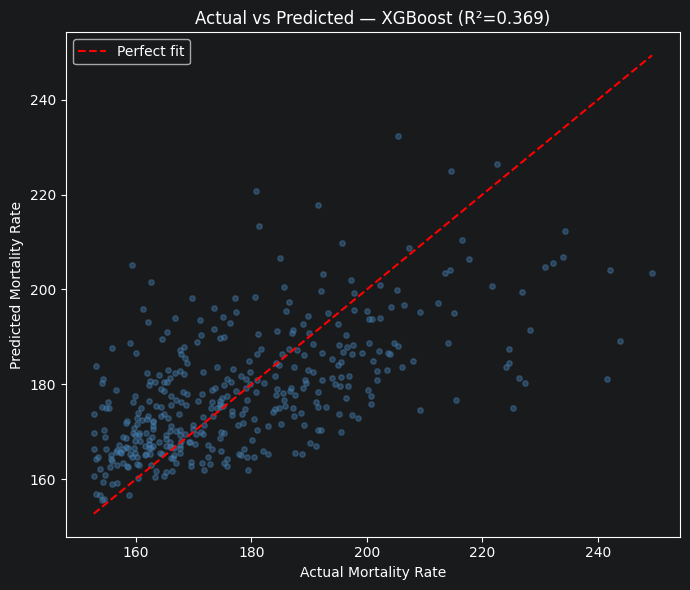

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, preds, alpha=0.4, s=15, color='steelblue')
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Mortality Rate')
ax.set_ylabel('Predicted Mortality Rate')
ax.set_title(f'Actual vs Predicted — XGBoost (R²={r2_score(y_test,preds):.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/actual_vs_predicted.png', dpi=150)
plt.show()